# Generate samples and fit a CSGD model to them

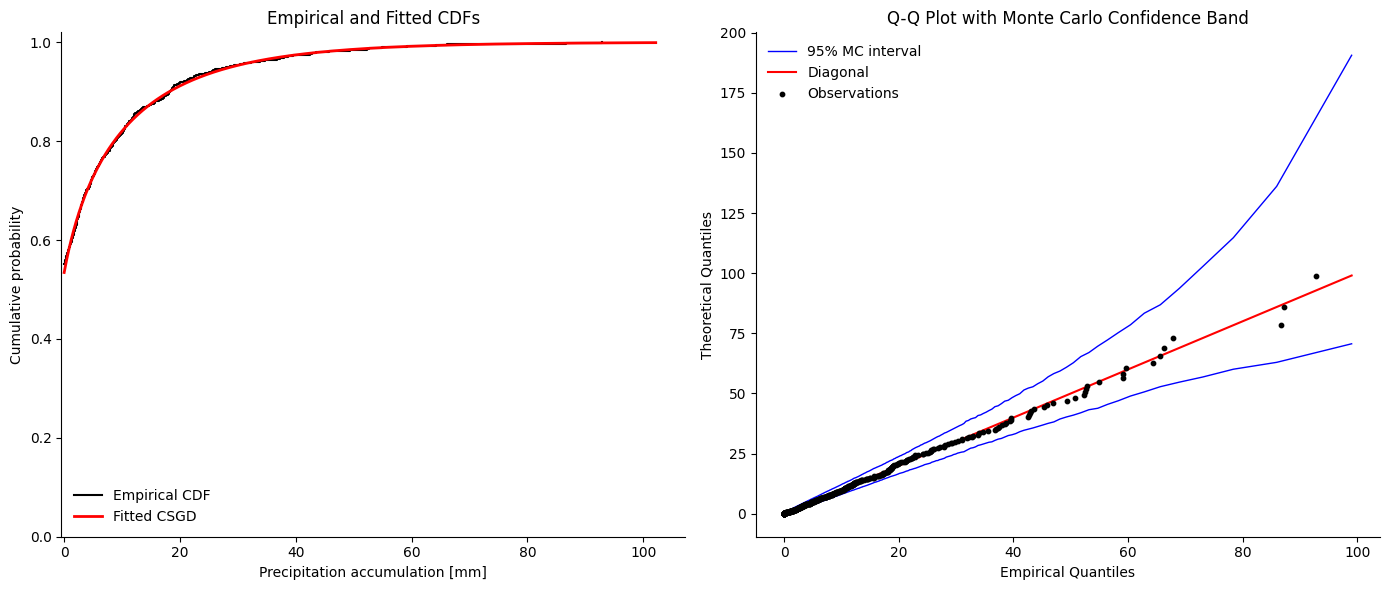

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pyenspp import CSGDFitter

# ============================================================
# 1️. Generate synthetic data from a known CSGD distribution
# ============================================================
np.random.seed(42)
n_samples = 1000
true_mu, true_sigma, true_delta = 8.0, 12.0, -4.0

true_fitter = CSGDFitter()
true_fitter.mu_ = true_mu
true_fitter.sigma_ = true_sigma
true_fitter.delta_ = true_delta
true_fitter.k_, true_fitter.theta_ = true_fitter.get_gamma_params(true_mu, true_sigma)
true_fitter.is_fitted = True

obs_data = true_fitter.rvs(n_samples)

# ============================================================
# 2. Fit CSGD to the synthetic data
# ============================================================
fitter = CSGDFitter()
fitter.fit(obs_data)

mu_hat, sigma_hat, delta_hat = fitter.params

# ============================================================
# 3. Use fitted parameters to compute theoretical CDF
# ============================================================
obs = np.asarray(obs_data)
n = len(obs)

n_zero = np.sum(obs == 0)
p0_emp = n_zero / n

pos = np.sort(obs[obs > 0])
n_pos = len(pos)
pos_probs = p0_emp + np.arange(1, n_pos + 1) / n

x_grid = np.linspace(0, pos.max() * 1.1, 1000)
cdf_fit = fitter.cdf(x_grid)

# ============================================================
# 4. Compute theoretical quantiles for Q-Q plot
# ============================================================
sorted_obs = np.sort(obs_data)
p = np.arange(1, n_samples + 1) / (n_samples + 1)  # plotting positions
theo_q = fitter.ppf(p)

# ============================================================
# 5. Monte Carlo to compute 95% confidence band for Q-Q plot
# ============================================================
lower, upper = fitter.qq_confidence_band(
    n_obs=n_samples,
    n_sim=2000,
    alpha=0.02,
    random_state=42
)

# ============================================================
# 6. Plotting
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------- 左图: 经验CDF vs 拟合CDF ---------
axes[0].step(
    np.concatenate(([0.0], pos)),
    np.concatenate(([p0_emp], pos_probs)),
    where='post',
    color='black',
    lw=1.5,
    label='Empirical CDF'
)

axes[0].plot(
    x_grid,
    cdf_fit,
    color='red',
    lw=2,
    label='Fitted CSGD'
)

axes[0].set_title('Empirical and Fitted CDFs')
axes[0].set_xlabel('Precipitation accumulation [mm]')
axes[0].set_ylabel('Cumulative probability')
axes[0].set_xlim(left=-0.5)
axes[0].set_ylim(0, 1.02)
axes[0].legend(frameon=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(theo_q, lower, color='blue', lw=1, label='95% MC interval')
axes[1].plot(theo_q, upper, color='blue', lw=1)

max_val = max(sorted_obs.max(), theo_q.max())
axes[1].plot([0, max_val], [0, max_val], 'r-', lw=1.5, label='Diagonal')

axes[1].scatter(sorted_obs, theo_q, s=10, c='black', zorder=3, label='Observations')

axes[1].set_xlabel('Empirical Quantiles')
axes[1].set_ylabel('Theoretical Quantiles')
axes[1].set_title('Q-Q Plot with Monte Carlo Confidence Band')
axes[1].legend(frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Usage of quantile mapping

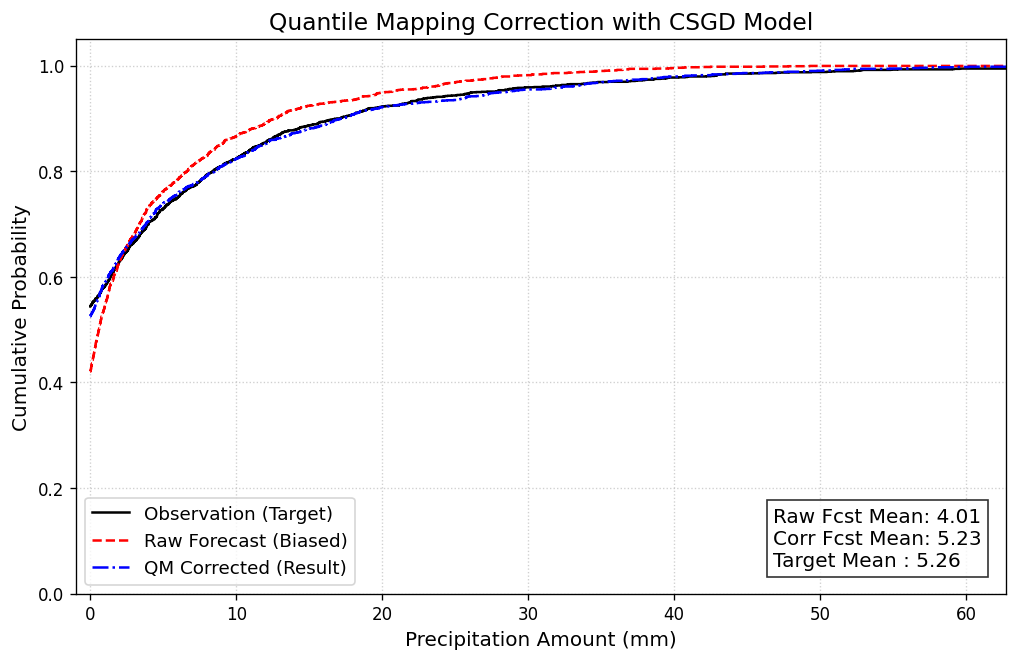

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from pyenspp import CSGDFitter, QuantileMapping

# ============================================================
# 1️⃣ Set random seed and simulation parameters
# ============================================================
np.random.seed(42)
n_samples = 2000  # Increase sample size to smooth the CDF curves

# ============================================================
# 2️⃣ Generate synthetic observation data (Target)
# ============================================================
# True underlying distribution parameters
true_mu, true_sigma, true_delta = 8.0, 12.0, -4.0 

# Create a "god view" fitter to generate observations
obs_gen = CSGDFitter()
obs_gen.mu_ = true_mu
obs_gen.sigma_ = true_sigma
obs_gen.delta_ = true_delta
obs_gen.k_, obs_gen.theta_ = obs_gen.get_gamma_params(true_mu, true_sigma)
obs_gen.is_fitted = True

# Generate observation samples
obs_data = obs_gen.rvs(n_samples)

# ============================================================
# 3️⃣ Generate biased forecast data (Source)
# ============================================================
# Forecast bias parameters:
# 1. Mean underestimated (mu=5.0 vs 8.0)
# 2. Smaller spread (sigma=8.0 vs 12.0)
# 3. Shift parameter larger (delta=-1.0 vs -4.0), fewer zeros, more small rainfall
fcst_mu, fcst_sigma, fcst_delta = 5.0, 8.0, -1.0

fcst_gen = CSGDFitter()
fcst_gen.mu_ = fcst_mu
fcst_gen.sigma_ = fcst_sigma
fcst_gen.delta_ = fcst_delta
fcst_gen.k_, fcst_gen.theta_ = fcst_gen.get_gamma_params(fcst_mu, fcst_sigma)
fcst_gen.is_fitted = True

# Generate historical forecast samples (for fitting)
fcst_history = fcst_gen.rvs(n_samples)

# Generate "future" forecast samples to test correction
fcst_future = fcst_gen.rvs(500)

# ============================================================
# 4️⃣ Apply Quantile Mapping correction
# ============================================================
# Instantiate QM and inject CSGDFitter as base
qm = QuantileMapping(base_fitter=CSGDFitter())

# Fit: learn the mapping between observations and historical forecasts
qm.fit(obs_data, fcst_history)

# Correct: apply mapping to forecast data
# Here we also correct historical data for visualization purposes
corrected_data = qm.correct(fcst_history)

# ============================================================
# 5️⃣ Plot ECDF (CDF) for CSGD data
# ============================================================
def plot_ecdf_for_csgd(data, label, color, linestyle='-'):
    """
    Plot empirical CDF for precipitation data with zeros (CSGD).
    Shows discrete jump at x=0.
    """
    data = np.asarray(data)
    n = len(data)
    
    # 1. Separate zeros and positive values
    n_zero = np.sum(data == 0)
    p_zero = n_zero / n
    
    pos_data = data[data > 0]
    n_pos = len(pos_data)
    
    if n_pos == 0:
        # All zeros
        plt.plot([0, 1], [p_zero, p_zero], label=label, color=color, linestyle=linestyle)
        return
    
    # 2. Sort positive values
    sorted_pos = np.sort(pos_data)
    
    # 3. Cumulative probability for positive values, starting from p_zero
    pos_probs = p_zero + np.arange(1, n_pos + 1) / n
    
    # 4. Construct full x and y
    x_vals = np.concatenate(([0.0], sorted_pos))
    y_vals = np.concatenate(([p_zero], pos_probs))
    
    # 5. Plot stepwise CDF (vertical jump at zero)
    plt.step(x_vals, y_vals, where='post', label=label, color=color, linestyle=linestyle)

plt.figure(figsize=(10, 6), dpi=120)

# 1. Observations (Target distribution - black solid line)
plot_ecdf_for_csgd(obs_data, "Observation (Target)", 'black', '-')

# 2. Raw forecast (biased - red dashed line)
plot_ecdf_for_csgd(fcst_history, "Raw Forecast (Biased)", 'red', '--')

# 3. QM-corrected forecast (aligned with target - blue dash-dot line)
plot_ecdf_for_csgd(corrected_data, "QM Corrected (Result)", 'blue', '-.')

# Chart decoration
plt.title("Quantile Mapping Correction with CSGD Model", fontsize=14)
plt.xlabel("Precipitation Amount (mm)", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# Limit x-axis for better visualization of main distribution
plt.xlim(-1, np.percentile(obs_data, 99) * 1.2)
plt.ylim(0, 1.05)

# Annotate statistics on the plot
text_str = (
    f"Raw Fcst Mean: {np.mean(fcst_history):.2f}\n"
    f"Corr Fcst Mean: {np.mean(corrected_data):.2f}\n"
    f"Target Mean : {np.mean(obs_data):.2f}"
)
plt.text(0.75, 0.05, text_str, transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8), fontsize=12)

plt.show()

# Usage of KAN-CSGD

Epoch 0: Train=4.7681, Val=4.8990
✅ Val loss improved to 4.899047
✅ Val loss improved to 4.776522
✅ Val loss improved to 4.662320
✅ Val loss improved to 4.552299
✅ Val loss improved to 4.444791
✅ Val loss improved to 4.341602
✅ Val loss improved to 4.241804
✅ Val loss improved to 4.150499
✅ Val loss improved to 4.070718
✅ Val loss improved to 4.000191
Epoch 10: Train=3.7732, Val=3.9378
✅ Val loss improved to 3.937774
✅ Val loss improved to 3.881061
✅ Val loss improved to 3.828732
✅ Val loss improved to 3.781224
✅ Val loss improved to 3.739087
✅ Val loss improved to 3.701103
✅ Val loss improved to 3.665154
✅ Val loss improved to 3.631539
✅ Val loss improved to 3.600429
✅ Val loss improved to 3.572565
Epoch 20: Train=3.3671, Val=3.5450
✅ Val loss improved to 3.544997
✅ Val loss improved to 3.519462
✅ Val loss improved to 3.496332
✅ Val loss improved to 3.473393
✅ Val loss improved to 3.453110
✅ Val loss improved to 3.432701
✅ Val loss improved to 3.412429
✅ Val loss improved to 3.393189


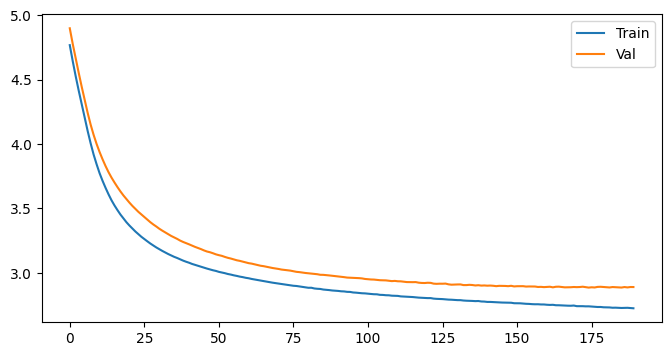

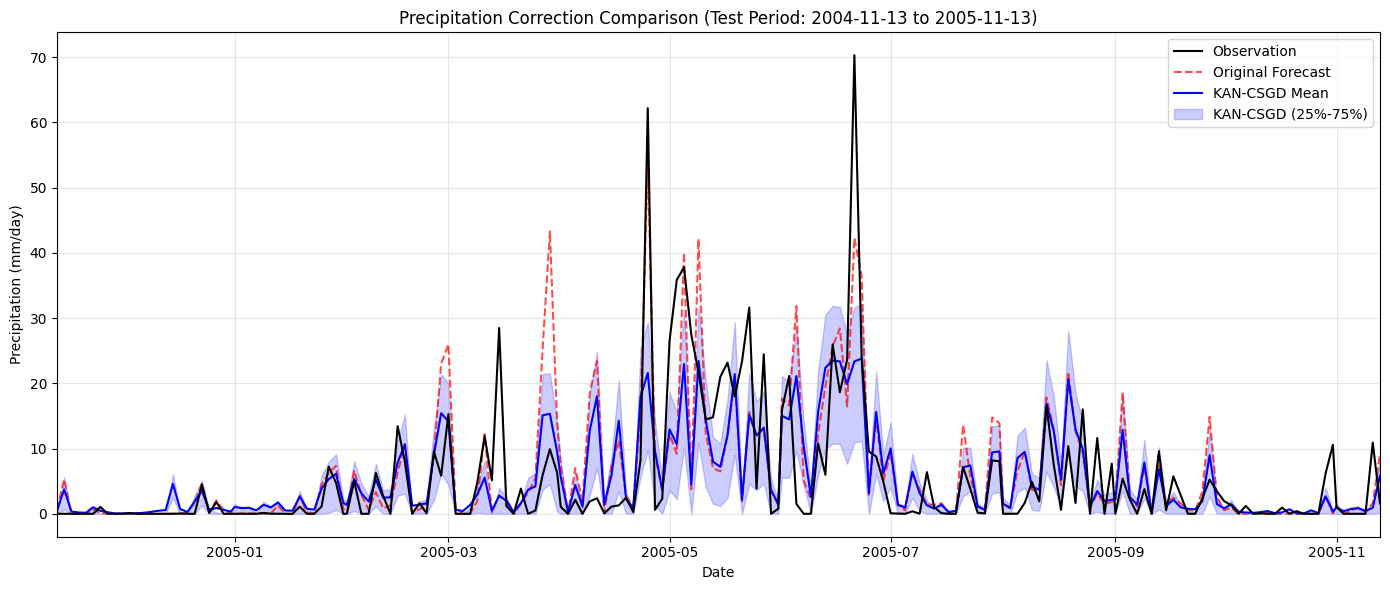

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from pyenspp import CSGDFitter, QuantileMapping
from pathlib import Path
import xarray as xr
import os
from pyenspp.utils import DistributionTransformer
from sklearn.preprocessing import MinMaxScaler
from pyenspp import KANCSGDRegression

current_dir = Path().resolve()  # get current directory
parent_dir = current_dir
data_path = parent_dir / "data"
fcst_data_path = os.path.join(data_path,  "fcst_m.nc")
obs_data_path = os.path.join(data_path,  "chirps.nc")

# We provide the calibration for the 1-day lead time, but not using LOOCV here for simplicity.
fcst = xr.open_dataset(fcst_data_path).sel(step='1 days')
obs = xr.open_dataset(obs_data_path)

train_start = '2005-11-13'
train_end = '2025-11-12'
test_start = '2004-11-13'
test_end = '2005-11-13'

def prepare_features(ds_fcst, ds_obs, time_slice):
    # Slice data
    f_sub = ds_fcst.sel(time=time_slice).prec
    o_sub = ds_obs.sel(time=f_sub.time).prec
    
    # Date Encoding: Sin/Cos transformation for seasonality
    doy = f_sub.time.dt.dayofyear
    sin_date = np.sin(2 * np.pi * doy / 366.0)
    cos_date = np.cos(2 * np.pi * doy / 366.0)
    
    # Extract precip values
    prec_val = f_sub.values.flatten()
    obs_val = o_sub.values.flatten()
    
    # Stack into 3D features: [Precip, Sin_Date, Cos_Date]
    features = np.column_stack([prec_val, sin_date, cos_date])
    return features, obs_val, f_sub.time

# Prepare raw datasets
X_train_raw, y_train, train_time = prepare_features(fcst, obs, slice(train_start, train_end))
X_test_raw, y_test, test_time = prepare_features(fcst, obs, slice(test_start, test_end))

# ==========================================
# 2. Preprocessing (Transform & Scaling)
# ==========================================
# A. Transform only the precipitation feature (index 0)
dist_tf = DistributionTransformer(method="asinh")
X_train_processed = X_train_raw.copy()
X_test_processed = X_test_raw.copy()

X_train_processed[:, 0] = dist_tf.fit_transform(X_train_raw[:, 0])
X_test_processed[:, 0] = dist_tf.transform(X_test_raw[:, 0])

# B. MinMaxScaler to [-1, 1] for KAN compatibility
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

# ==========================================
# 3. Model Training
# ==========================================
model_cfg = dict(
    hidden_dim=8,     
    grid_size=5,       
    lr=0.005,          
    n_epochs=500,     
    batch_size=512,   
    patience=15,
    verbose=True,
    save_path="best_kan_model.pth"
)

model = KANCSGDRegression(**model_cfg)
model.fit(X_train_scaled, y_train)

# ==========================================
# 4. Correction & Ensemble Generation
# ==========================================
# Generate 500 members for the test period
n_members = 500
corrected_ensemble = model.correct(X_test_scaled, n_members=n_members, mode='quantile')

# ==========================================
# 5. Visualization of Results
# ==========================================
# Display Loss Curve
plt.figure(figsize=(8, 4))
model.plot_loss()

# Calculate statistics for plotting
# Note: Raw ensemble is often available in the nc file, 
# but here we use the raw control forecast (prec) as the 'original' for simplicity.
corr_mean = np.mean(corrected_ensemble, axis=1)
corr_p25 = np.percentile(corrected_ensemble, 25, axis=1)
corr_p75 = np.percentile(corrected_ensemble, 75, axis=1)

plt.figure(figsize=(14, 6))

# Plot Observed
plt.plot(test_time, y_test, color='black', label='Observation', linewidth=1.5, zorder=5)

# Plot Original Forecast (from input features)
plt.plot(test_time, X_test_raw[:, 0], color='red', linestyle='--', label='Original Forecast', alpha=0.7)

# Plot Corrected Ensemble Mean
plt.plot(test_time, corr_mean, color='blue', label='KAN-CSGD Mean', linewidth=1.5)

# Fill 25th-75th percentile range for Corrected Ensemble
plt.fill_between(test_time, corr_p25, corr_p75, color='blue', alpha=0.2, label='KAN-CSGD (25%-75%)')

plt.title(f"Precipitation Correction Comparison (Test Period: {test_start} to {test_end})")
plt.ylabel("Precipitation (mm/day)")
plt.xlabel("Date")
plt.legend(loc='upper right')
plt.xlim(test_time[0], test_time[-1])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()